In [49]:
import numpy as np
import pandas as pd

In [50]:
data = pd.read_csv(
    "/home/julia/Рабочий стол/code/NSU_AI-Robotics/tvims/House-Prices.csv"
)
df = pd.DataFrame(data)
df["waterbody"] = df["waterbody"].fillna("None")
df = df.dropna()
df.head()

,price,resid_area,air_qual,room_num,age,dist1,dist2,dist3,dist4,teachers,poor_prop,airport,n_hos_beds,n_hot_rooms,waterbody,rainfall,bus_ter,parks,Sold
0,24.0,32.31,0.538,6.575,65.2,4.35,3.81,4.18,4.01,24.7,4.98,YES,5.480,11.1920,River,23,YES,0.049347,0
1,21.6,37.07,0.469,6.421,78.9,4.99,4.70,5.12,5.06,22.2,9.14,NO,7.332,12.1728,Lake,42,YES,0.046146,1
2,34.7,37.07,0.469,7.185,61.1,5.03,4.86,5.01,4.97,22.2,4.03,NO,7.394,101.1200,None,38,YES,0.045764,0
3,33.4,32.18,0.458,6.998,45.8,6.21,5.93,6.16,5.96,21.3,2.94,YES,9.268,11.2672,Lake,45,YES,0.047151,0
4,36.2,32.18,0.458,7.147,54.2,6.16,5.86,6.37,5.86,21.3,5.33,NO,8.824,11.2896,Lake,55,YES,0.039474,0


In [51]:
groups = {
    "None": df[df["waterbody"] == "None"],
    "River": df[df["waterbody"] == "River"],
    "Lake": df[df["waterbody"] == "Lake"],
    "Lake and River": df[df["waterbody"] == "Lake and River"],
}

In [52]:
from scipy.stats import beta

your_p = 0.6
your_sure = 0.1
your_p = float(your_p)
your_sure = float(your_sure)
print ("that's your guess", your_p, "and you're this sure", your_sure)
# короче нам дали априорное мат ожидание и априорное стандартное отклоенние
# а нам надо откудато бета распределение достатть
dispersia = your_sure ** 2 #стандартное отклонение на 2
s = your_p * (1 - your_p) / dispersia - 1 
a = your_p * s
b = (1 - your_p) * s
aprior_p = beta(a=1, b=1)

that's your guess 0.6 and you're this sure 0.1


In [53]:
results = {}

for name, group in groups.items():
    n = len(group)
    if n == 0:
        print(f"Группа '{name}' пуста — пропускаем.")
        continue
    k = group["Sold"].sum()
    # k - число продаж в этой группе по данным. (это не p)
    # апостериорное распределение p тоже бета, найдем параметры
    apost_a = a + k
    apost_b = b + (n - k)

    apost_mean = apost_a/(apost_a + apost_b)

    apost_dispersia = (apost_a*apost_b)/((apost_a + apost_b)**2 * (apost_a + apost_b + 1))

    apost_std = np.sqrt(apost_dispersia)
    results[name] = {
        "n": n,
        "k": k,
        "apost_a": apost_a,
        "apost_b": apost_b,
        "mean": apost_mean,
        "std": apost_std,
    }

    # Вывод
    print(f"Группа: {name}")
    print(f"  Домов: {n}, Продано: {k}")
    print(f"  Апостериор: Beta(a={apost_a:.2f}, b={apost_b:.2f})")
    print(f"  Апостериорное среднее: {apost_mean:.4f}")
    print(f"  Апостериорное std:     {apost_std:.4f}")
    print(
        f"  Неопределённость изменилась: {your_sure:.4f} -> {apost_std:.4f} (уменьшилась в {your_sure/apost_std:.2f} раз)\n"
    )

Группа: None
  Домов: 155, Продано: 68
  Апостериор: Beta(a=81.80, b=96.20)
  Апостериорное среднее: 0.4596
  Апостериорное std:     0.0372
  Неопределённость изменилась: 0.1000 -> 0.0372 (уменьшилась в 2.68 раз)

Группа: River
  Домов: 178, Продано: 89
  Апостериор: Beta(a=102.80, b=98.20)
  Апостериорное среднее: 0.5114
  Апостериорное std:     0.0352
  Неопределённость изменилась: 0.1000 -> 0.0352 (уменьшилась в 2.84 раз)

Группа: Lake
  Домов: 94, Продано: 37
  Апостериор: Beta(a=50.80, b=66.20)
  Апостериорное среднее: 0.4342
  Апостериорное std:     0.0456
  Неопределённость изменилась: 0.1000 -> 0.0456 (уменьшилась в 2.19 раз)

Группа: Lake and River
  Домов: 71, Продано: 32
  Апостериор: Beta(a=45.80, b=48.20)
  Апостериорное среднее: 0.4872
  Апостериорное std:     0.0513
  Неопределённость изменилась: 0.1000 -> 0.0513 (уменьшилась в 1.95 раз)



In [54]:
order = ["None", "River", "Lake", "Lake and River"]

alpha_curr = a
beta_curr = b

posteriors_seq = [("Априор", alpha_curr, beta_curr)]

print(f"Начальный априор: a={alpha_curr:.3f}, b={beta_curr:.3f}")
print(
    f"  Среднее = {alpha_curr / (alpha_curr + beta_curr):.4f}, "
    f"Std = {np.sqrt((alpha_curr * beta_curr) / ((alpha_curr + beta_curr)**2 * (alpha_curr + beta_curr + 1))):.4f}\n"
)

for step, group_name in enumerate(order, 1):
    group = groups[group_name]
    n = len(group)
    if n == 0:
        print(f"Шаг {step}: группа '{group_name}' пуста — пропускаем.")
        continue

    k = int(group["Sold"].sum())
    print(f"Шаг {step}: обновляем данными из группы '{group_name}' (n={n}, k={k})")

    alpha_curr += k
    beta_curr += n - k

    curr_mean = alpha_curr / (alpha_curr + beta_curr)
    curr_var = (alpha_curr * beta_curr) / (
        (alpha_curr + beta_curr) ** 2 * (alpha_curr + beta_curr + 1)
    )
    curr_std = np.sqrt(curr_var)

    posteriors_seq.append((f"После {group_name}", alpha_curr, beta_curr))

    print(f"  Новое распределение: Beta(a={alpha_curr:.2f}, b={beta_curr:.2f})")
    print(f"     Среднее = {curr_mean:.4f}, Std = {curr_std:.4f}\n")

Начальный априор: a=13.800, b=9.200
  Среднее = 0.6000, Std = 0.1000

Шаг 1: обновляем данными из группы 'None' (n=155, k=68)
  Новое распределение: Beta(a=81.80, b=96.20)
     Среднее = 0.4596, Std = 0.0372

Шаг 2: обновляем данными из группы 'River' (n=178, k=89)
  Новое распределение: Beta(a=170.80, b=185.20)
     Среднее = 0.4798, Std = 0.0264

Шаг 3: обновляем данными из группы 'Lake' (n=94, k=37)
  Новое распределение: Beta(a=207.80, b=242.20)
     Среднее = 0.4618, Std = 0.0235

Шаг 4: обновляем данными из группы 'Lake and River' (n=71, k=32)
  Новое распределение: Beta(a=239.80, b=281.20)
     Среднее = 0.4603, Std = 0.0218



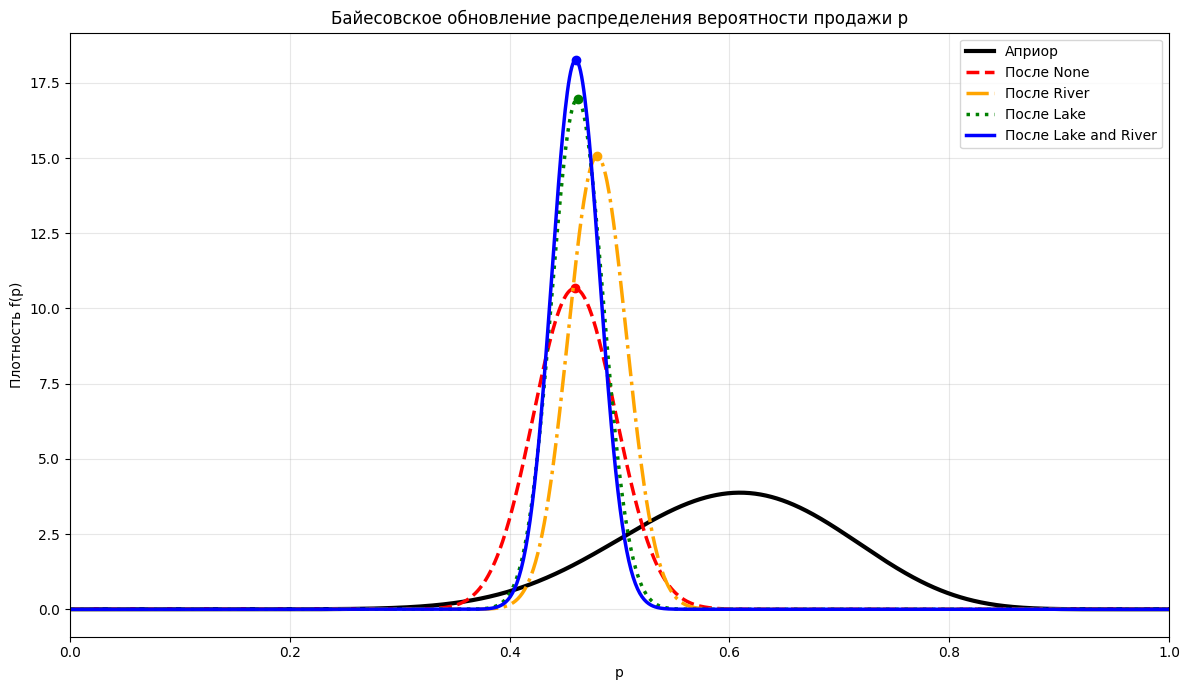

In [55]:
import matplotlib.pyplot as plt

x = np.linspace(0, 1, 1000)
plt.figure(figsize=(12, 7))
x = np.linspace(0.001, 0.999, 1000) 

plt.plot(
    x, beta.pdf(x, a, b), label="Априор", linewidth=3, color="black", linestyle="-"
)

colors = ["red", "orange", "green", "blue"]
linestyles = ["--", "-.", ":", "-"]
for i, (label, a_i, b_i) in enumerate(posteriors_seq[1:], 0):
    plt.plot(
        x,
        beta.pdf(x, a_i, b_i),
        label=label,
        linewidth=2.5,
        color=colors[i % len(colors)],
        linestyle=linestyles[i % len(linestyles)],
    )
    mean = a_i / (a_i + b_i)
    plt.plot(
        mean, beta.pdf(mean, a_i, b_i), "o", color=colors[i % len(colors)], markersize=6
    )

plt.title("Байесовское обновление распределения вероятности продажи p")
plt.xlabel("p")
plt.ylabel("Плотность f(p)")
plt.legend()
plt.grid(alpha=0.3)
plt.xlim(0, 1)
plt.tight_layout()
plt.show()